# Logistic Regression Model

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

### Ordinal Encoding Categorical Data

In [28]:
df = pd.read_csv('Datasets/train.csv')

def clean(df):
    df = df.drop(['Cabin', 'Ticket', 'Name', 'PassengerId'], axis=1)
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 3, 'C': 2, 'Q': 1, np.nan: -1})
    df = df.fillna(-1)
    return df

df = clean(df)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,3
1,1,1,1,38.0,1,0,71.2833,2
2,1,3,1,26.0,0,0,7.9250,3
3,1,1,1,35.0,1,0,53.1000,3
4,0,3,0,35.0,0,0,8.0500,3


### Splitting Dataset

In [29]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Feature Scaling

In [30]:
scaler = StandardScaler()
scaler = scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Training Model

In [31]:
# Use Grid Search Cross Validation to find the optimal c parameter and features
rfe_lr = RFE(LogisticRegression(
    random_state = 1000,
    solver = 'lbfgs',
    max_iter=5000
))
grid = GridSearchCV(
    estimator = rfe_lr,
    param_grid = {"n_features_to_select": [1, 2, 3, 4, 5, 6, 7],
                  "estimator__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
                  }
)

grid = grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print(grid.best_params_)
pd.DataFrame(grid.cv_results_).head(10)

{'estimator__C': 0.01, 'n_features_to_select': 6}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator__C,param_n_features_to_select,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007871,0.003348,0.000469,0.000132,0.0001,1,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.619718,0.619718,0.619718,0.617985,0.002123,41
1,0.004485,0.000524,0.000293,0.000020,0.0001,2,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.619718,0.619718,0.619718,0.617985,0.002123,41
2,0.003102,0.000115,0.000262,0.000009,0.0001,3,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.619718,0.619718,0.619718,0.617985,0.002123,41
3,0.002486,0.000048,0.000230,0.000004,0.0001,4,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.619718,0.619718,0.619718,0.617985,0.002123,41
4,0.001963,0.000099,0.000255,0.000015,0.0001,5,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.619718,0.619718,0.619718,0.617985,0.002123,41
5,0.001337,0.000017,0.000225,0.000003,0.0001,6,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.619718,0.619718,0.619718,0.617985,0.002123,41
6,0.000732,0.000011,0.000222,0.000003,0.0001,7,"{'estimator__C': 0.0001, 'n_features_to_select...",0.615385,0.615385,0.619718,0.619718,0.619718,0.617985,0.002123,41
7,0.003682,0.000059,0.000257,0.000020,0.0010,1,"{'estimator__C': 0.001, 'n_features_to_select'...",0.615385,0.615385,0.619718,0.619718,0.619718,0.617985,0.002123,41
8,0.003244,0.000119,0.000231,0.000005,0.0010,2,"{'estimator__C': 0.001, 'n_features_to_select'...",0.615385,0.615385,0.619718,0.619718,0.619718,0.617985,0.002123,41
9,0.002700,0.000073,0.000234,0.000014,0.0010,3,"{'estimator__C': 0.001, 'n_features_to_select'...",0.643357,0.636364,0.647887,0.619718,0.626761,0.634817,0.010383,38


### Test model on test data

In [32]:
from sklearn.metrics import accuracy_score

test_predict = best_model.predict(X_test)
score = accuracy_score(y_test, test_predict)
print(score)

0.7877094972067039


In [33]:
# Use the best model to predict the test data

df_test = pd.read_csv("Datasets/test.csv")
passenger = df_test['PassengerId']
df_test = clean(df_test)
df_test = scaler.transform(df_test)
prediction = best_model.predict(df_test)

results = pd.DataFrame({"PassengerId": passenger, "Survived": prediction})
results.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [34]:
results.to_csv('Datasets/LogisticRegression.csv', index = False)

# Decision Tree Model

In [35]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(criterion='gini',
                                       random_state=1000)

grid_dt = GridSearchCV(
    estimator= decision_tree,
    param_grid= {"max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}
)

grid_dt = grid_dt.fit(X_train, y_train)
best_model_dt = grid_dt.best_estimator_

print(grid_dt.best_params_)
pd.DataFrame(grid_dt.cv_results_).head(10)

{'max_depth': 5}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001538,0.000608,0.000684,0.000291,2,{'max_depth': 2},0.776224,0.825175,0.774648,0.838028,0.760563,0.794928,0.030707,7
1,0.000721,0.000103,0.000471,0.000388,3,{'max_depth': 3},0.783217,0.811189,0.774648,0.838028,0.753521,0.792121,0.029481,9
2,0.000638,0.000009,0.000235,0.000003,4,{'max_depth': 4},0.762238,0.804196,0.767606,0.823944,0.823944,0.796385,0.026737,5
3,0.000694,0.000061,0.000294,0.000139,5,{'max_depth': 5},0.790210,0.825175,0.809859,0.845070,0.767606,0.807584,0.026907,1
4,0.000658,0.000009,0.000212,0.000001,6,{'max_depth': 6},0.818182,0.811189,0.816901,0.795775,0.767606,0.801930,0.018921,4
5,0.000674,0.000016,0.000204,0.000006,7,{'max_depth': 7},0.797203,0.811189,0.795775,0.795775,0.767606,0.793509,0.014195,8
6,0.000706,0.000064,0.000227,0.000037,8,{'max_depth': 8},0.790210,0.811189,0.802817,0.802817,0.816901,0.804787,0.009033,2
7,0.000723,0.000042,0.000207,0.000010,9,{'max_depth': 9},0.783217,0.783217,0.788732,0.802817,0.816901,0.794977,0.013098,6
8,0.000679,0.000012,0.000193,0.000006,10,{'max_depth': 10},0.790210,0.797203,0.795775,0.809859,0.816901,0.801990,0.009845,3
9,0.000659,0.000014,0.000184,0.000004,11,{'max_depth': 11},0.790210,0.769231,0.774648,0.788732,0.795775,0.783719,0.010048,11


In [36]:
test_predict = best_model_dt.predict(X_test)
score = accuracy_score(y_test, test_predict)
print(score)

0.7988826815642458


### Visualize Decision Tree

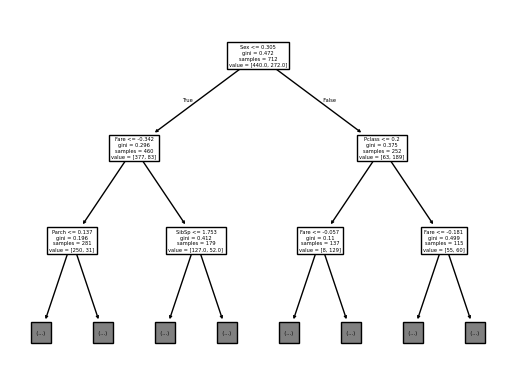

In [45]:
from sklearn import tree
import matplotlib.pyplot as plt

tree.plot_tree(best_model_dt, max_depth=2, feature_names= X.columns)
plt.show()


### Predicting Kaggle Testing Data

In [48]:
kaggle_dt_pred = best_model_dt.predict(df_test)

results = pd.DataFrame({"PassengerId": passenger, "Survived": kaggle_dt_pred})
results.head(10)
results.to_csv('Datasets/Decision_Tree.csv', index=False)